In [1]:
import pandas as pd

orders = pd.read_csv("../data/cleaned/orders_cleaned.csv")

products = pd.read_csv("../data/cleaned/products_cleaned.csv")

customers = pd.read_csv("../data/cleaned/customers_cleaned.csv")

returns = pd.read_csv("../data/cleaned/returns_cleaned.csv")

# Display the first few rows of each DataFrame to verify successful loading
print("Orders DataFrame:")
print(orders.head())
print("\nProducts DataFrame:")
print(products.head())
print("\nCustomers DataFrame:")
print(customers.head())
print("\nReturns DataFrame:")
print(returns.head())

Orders DataFrame:
  order_id customer_id product_id  order_date  quantity  price  revenue  \
0   O00001       C0349        P34  2024-03-15         1  973.0    973.0   
1   O00002       C0076        P33  2024-12-08         2  891.0   1782.0   
2   O00003       C0079        P53  2024-03-22         1  212.0    212.0   
3   O00004       C0413        P28  2024-07-16         2  471.0    942.0   
4   O00005       C0069        P24  2024-03-04         1  755.0    755.0   

        city  year  month  day  
0     Mumbai  2024      3   15  
1  Ahmedabad  2024     12    8  
2  Hyderabad  2024      3   22  
3       Pune  2024      7   16  
4  Ahmedabad  2024      3    4  

Products DataFrame:
  product_id                                       product_name  \
0         P1                     Austin Hot & Cold Water Bottle   
1         P2                 Crypto Art Hot & Cold Water Bottle   
2         P3  Pexpo Amaze Thermo Steel Bottle | Tri-Ply Vacu...   
3         P4              Craft SS Water Bot

In [2]:
print("Orders shape:", orders.shape)
print("Products shape:", products.shape)
print("Customers shape:", customers.shape)
print("Returns shape:", returns.shape)


Orders shape: (3000, 11)
Products shape: (62, 8)
Customers shape: (500, 4)
Returns shape: (300, 2)


In [3]:
orders_enriched = (
    orders
    .merge(products, on="product_id", how="left")
    .merge(customers, on="customer_id", how="left")
)

orders_enriched.head()


,order_id,customer_id,product_id,order_date,quantity,price_x,revenue,city_x,year,month,...,product_name,raw_price,collection,product_url,price_y,product_type,product_line,city_y,gender,age_group
0,O00001,C0349,P34,2024-03-15,1,973.0,973.0,Mumbai,2024,3,...,Pexpo Oslo Thermo Steel Bottle | Tri-Ply Vacuu...,₹ 973.00,Art,https://pexpo.in/products/oslo-black-floral,973.0,Bottle,Pexpo,Mumbai,F,36-45
1,O00002,C0076,P33,2024-12-08,2,891.0,1782.0,Ahmedabad,2024,12,...,Pexpo Texas Thermo Steel Bottle | Tri-Ply Vacu...,₹ 891.00,Art,https://pexpo.in/products/texas-moana-doll-pri...,891.0,Bottle,Pexpo,Ahmedabad,M,18-25
2,O00003,C0079,P53,2024-03-22,1,212.0,212.0,Hyderabad,2024,3,...,Atlas Push Button Sipper cap,₹ 212.00,Accessories,https://pexpo.in/products/pexpo-atlas-push-but...,212.0,Accessories,Atlas,Hyderabad,M,18-25
3,O00004,C0413,P28,2024-07-16,2,471.0,942.0,Pune,2024,7,...,Alaska Warm & Cold Water Bottle,₹ 471.00,Kids,https://pexpo.in/products/alaska-warm-cold-wat...,471.0,Bottle,Alaska,Pune,F,36-45
4,O00005,C0069,P24,2024-03-04,1,755.0,755.0,Ahmedabad,2024,3,...,Piano Art Hot & Cold Water Bottle,₹ 755.00,Kids,https://pexpo.in/products/piano-artful-vacuum-...,755.0,Bottle,Piano,Ahmedabad,M,36-45


In [4]:
total_revenue = orders_enriched["revenue"].sum()
total_orders = orders_enriched["order_id"].nunique()
avg_order_value = total_revenue / total_orders

total_revenue, total_orders, avg_order_value


(np.float64(2501783.0), 3000, np.float64(833.9276666666667))

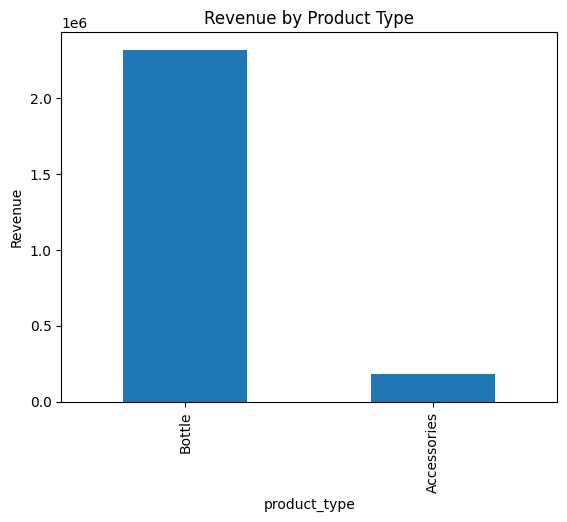

In [5]:
import matplotlib.pyplot as plt

rev_by_type = (
    orders_enriched
    .groupby("product_type")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

rev_by_type.plot(kind="bar")
plt.title("Revenue by Product Type")
plt.ylabel("Revenue")
plt.show()


In [6]:
product_revenue = (
    orders_enriched
    .groupby("product_name")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue.head(10)


product_name
Piano Art Hot & Cold Water Bottle                                                                                   158550.0
Pexpo Pixy Art Stainless Steel Bottle | Tri-Ply Vacuum Insulated Hot & Cold Flask | For Kids                        156216.0
Pexpo Oslo Thermo Steel Bottle | Tri-Ply Vacuum Insulated Hot & Cold Flask | For Daily Use - Black Flower Print     123571.0
Pexpo Texas Thermo Steel Bottle | Tri-Ply Vacuum Insulated Hot & Cold Flask | For School - Sea Green Doll Print     113157.0
Pexpo Oslo Thermo Steel Bottle | Tri-Ply Vacuum Insulated Hot & Cold Flask | For Daily Use - Pink Flamingo Print    111895.0
Pexpo Texas Thermo Steel Bottle | Tri-Ply Vacuum Insulated Hot & Cold Flask | For School - Pink Flower Print        102465.0
Poggo Art Hot & Cold Water Bottle                                                                                   100860.0
Pexpo Pico Art Stainless Steel Bottle | Tri-Ply Vacuum Insulated Hot & Cold Flask | For Kids                    

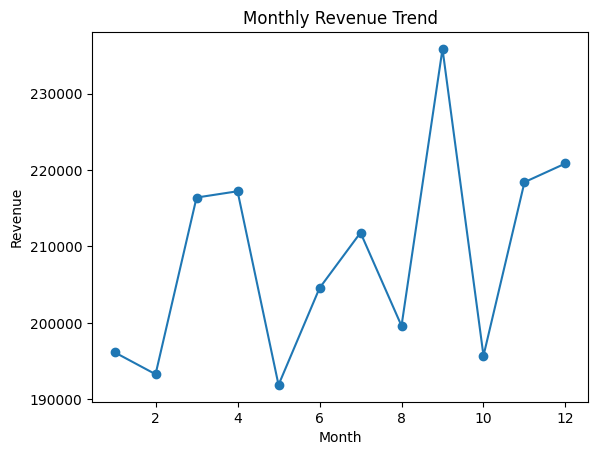

In [7]:
monthly_sales = (
    orders_enriched
    .groupby("month")["revenue"]
    .sum()
)

monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()


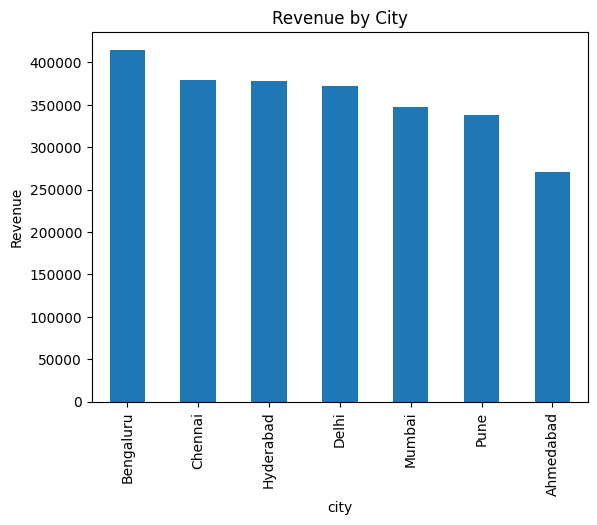

In [8]:
orders_enriched = orders_enriched.rename(columns={"city_x": "city"})
orders_enriched = orders_enriched.drop(columns=["city_y"])


city_revenue = (
    orders_enriched
    .groupby("city")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

city_revenue.plot(kind="bar")
plt.title("Revenue by City")
plt.ylabel("Revenue")
plt.show()


In [9]:
returned_orders = returns["order_id"].nunique()
return_rate = returned_orders / total_orders * 100

return_rate


10.0

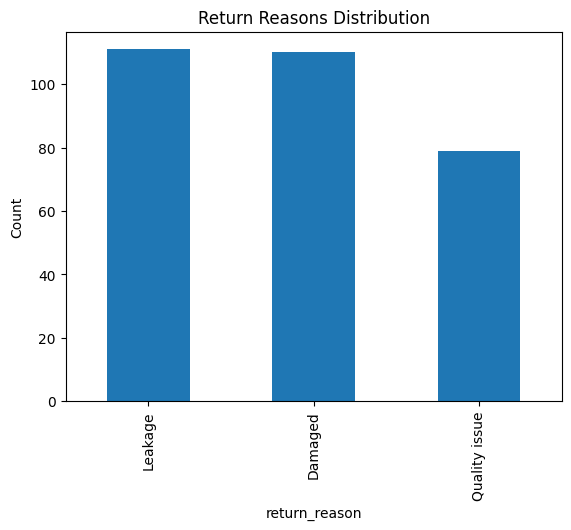

In [10]:
returns["return_reason"].value_counts().plot(kind="bar")
plt.title("Return Reasons Distribution")
plt.ylabel("Count")
plt.show()


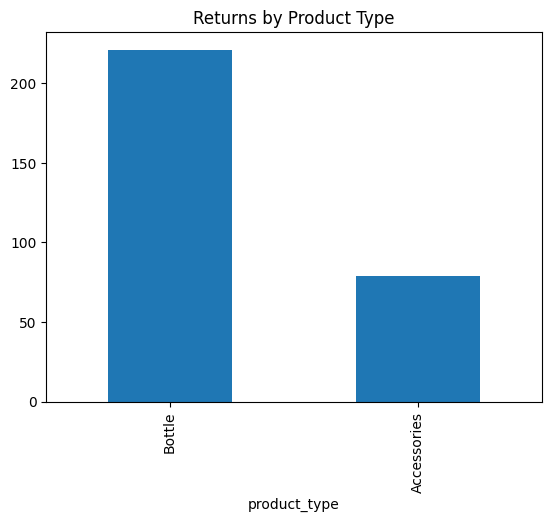

In [11]:
returns_enriched = returns.merge(
    orders_enriched[["order_id", "product_type"]],
    on="order_id",
    how="left"
)

returns_enriched["product_type"].value_counts().plot(kind="bar")
plt.title("Returns by Product Type")
plt.show()
